In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ebthalfallatah/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv("/Users/ebthalfallatah/Downloads/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

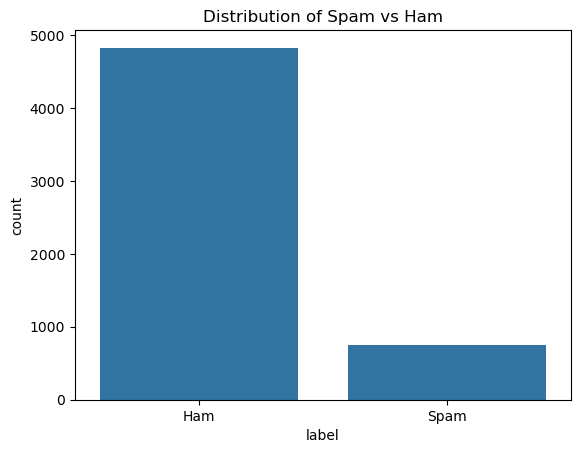

In [5]:
sns.countplot(x='label', data=df)
plt.title("Distribution of Spam vs Ham")
plt.xticks([0,1], ['Ham', 'Spam'])
plt.show()

In [6]:
def clean_text(msg):
    msg = msg.lower()
    msg = re.sub(r'\d+', '', msg)  # إزالة الأرقام
    msg = msg.translate(str.maketrans('', '', string.punctuation))  # إزالة الترقيم
    msg = msg.strip()
    stop_words = set(stopwords.words('english'))
    msg = ' '.join([word for word in msg.split() if word not in stop_words])
    return msg

df['cleaned'] = df['message'].apply(clean_text)
df[['message', 'cleaned']].head()

,message,cleaned
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [7]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned'])
y = df['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [10]:
def evaluate_model(name, y_true, y_pred):
    print(f"🔹 {name} Evaluation:")
    print(classification_report(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("-" * 50)

evaluate_model("Naive Bayes", y_test, nb_preds)
evaluate_model("Logistic Regression", y_test, lr_preds)
evaluate_model("Random Forest", y_test, rf_preds)

🔹 Naive Bayes Evaluation:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

Accuracy: 0.967713004484305
Confusion Matrix:
 [[965   0]
 [ 36 114]]
--------------------------------------------------
🔹 Logistic Regression Evaluation:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.63      0.76       150

    accuracy                           0.95      1115
   macro avg       0.95      0.81      0.87      1115
weighted avg       0.95      0.95      0.94      1115

Accuracy: 0.947085201793722
Confusion Matrix:
 [[961   4]
 [ 55  95]]
--------------------------------------------------
🔹 Random Forest Evaluation:
              pr

In [11]:
results = pd.DataFrame({'message': df['message'][y_test.index],
                        'actual': y_test,
                        'predicted': lr_preds})
wrong = results[results['actual'] != results['predicted']]
wrong.head()

,message,actual,predicted
1044,We know someone who you know that fancies you....,1,0
683,Hi I'm sue. I am 20 years old and work as a la...,1,0
4294,HMV BONUS SPECIAL 500 pounds of genuine HMV vo...,1,0
4733,Buy Space Invaders 4 a chance 2 win orig Arcad...,1,0
4700,I liked the new mobile,0,1
